In [1]:
pip install cvxopt

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

   ---------------------------------------- 0.0/13.6 MB ? eta -:--:--
    --------------------------------------- 0.3/13.6 MB ? eta -:--:--
   -- ------------------------------------- 0.8/13.6 MB 2.1 MB/s eta 0:00:07
   --- ------------------------------------ 1.3/13.6 MB 2.7 MB/s eta 0:00:05
   --- ------------------------------------ 1.3/13.6 MB 2.7 MB/s eta 0:00:05
   --- ------------------------------------ 1.3/13.6 MB 2.7 MB/s eta 0:00:05
   --- ------------------------------------ 1.3/13.6 MB 2.7 MB/s eta 0:00:05
   --- ------------------------------------ 1.3/13.6 MB 2.7 MB/s eta 0:00:05
   ----- ---------------------------------- 1.8/13.6 MB 1.0 MB/s eta 0:00:12
   ------ --------------------------------- 2.1/13.6 MB 1.0 MB/s eta 0:00:12
   ------ --------------------------------- 2.4/13.6 MB 1.1 MB/s eta 0:00:11
   ------- ------------

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [4]:
import pandas as pd

df = pd.read_csv("iris.csv")

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [5]:
 # Display unique species
print(df["species"].unique())

# Count the number of samples in each class
print(df["species"].value_counts())

['setosa' 'versicolor' 'virginica']
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [6]:
# Remove Virginica
df = df[df["species"] != "virginica"]

# Reset row numbers
df = df.reset_index(drop=True)

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [7]:
print(df["species"].unique())

['setosa' 'versicolor']


In [8]:
print(df["species"].value_counts())

species
setosa        50
versicolor    50
Name: count, dtype: int64


In [9]:
# Select the required feature columns
X = df[["petal_length", "petal_width"]]

# Convert the DataFrame to a NumPy array
X = X.to_numpy()
print(X.shape)

(100, 2)


In [10]:
# Select the target column
y = df["species"]

# Convert it to a NumPy array
y = y.to_numpy()
print(y[:10])

['setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa' 'setosa'
 'setosa' 'setosa']


In [11]:
import numpy as np

y = np.where(y == "setosa", -1, 1)
print(y[:10])

[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)
print(X[:5])

[[-1.01297765 -1.04211089]
 [-1.01297765 -1.04211089]
 [-1.08231219 -1.04211089]
 [-0.94364311 -1.04211089]
 [-1.01297765 -1.04211089]]


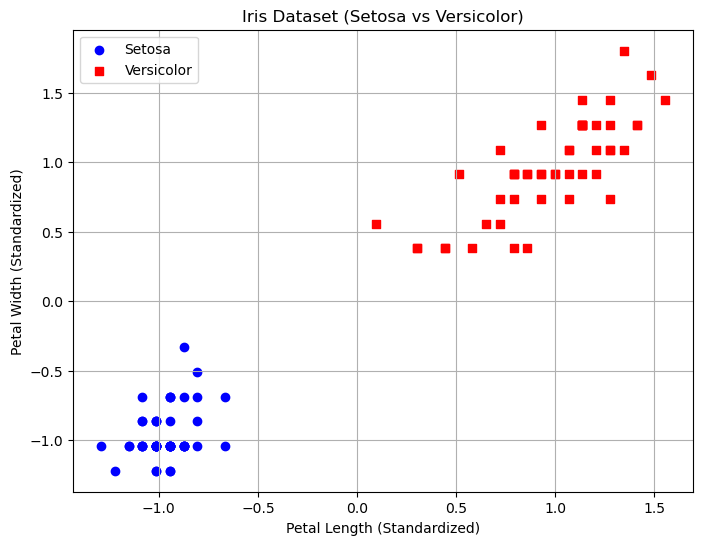

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X[y==-1,0],
    X[y==-1,1],
    color="blue",
    marker='o',
    label="Setosa"
)

plt.scatter(
    X[y==1,0],
    X[y==1,1],
    color="red",
    marker='s',
    label="Versicolor"
)

plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Iris Dataset (Setosa vs Versicolor)")
plt.grid(True)
plt.legend()

plt.show()

In [14]:
print("Feature matrix shape :", X.shape)
print("Target vector shape  :", y.shape)

print("\nFirst five feature vectors:")
print(X[:5])

print("\nFirst five labels:")
print(y[:5])

Feature matrix shape : (100, 2)
Target vector shape  : (100,)

First five feature vectors:
[[-1.01297765 -1.04211089]
 [-1.01297765 -1.04211089]
 [-1.08231219 -1.04211089]
 [-0.94364311 -1.04211089]
 [-1.01297765 -1.04211089]]

First five labels:
[-1 -1 -1 -1 -1]


In [2]:
from cvxopt import matrix, solvers
import numpy as np

αmax​∑αi​−21​∑∑αi​αj​yi​yj​xiT​x

L(w,b,α)=21​∥w∥2−i∑​αi​[yi​(wTxi​+b)−1].

w=i∑​αi​yi​xi​, i∑​αi​yi​=0.

In [15]:
class QuadraticSVM:

    def __init__(self):
        self.w = None
        self.b = None
        self.alphas = None
        self.support_vectors = None

    def fit(self, X, y):

        n_samples, n_features = X.shape

        # -----------------------------
        # Step 1: Compute Gram Matrix
        # -----------------------------
        K = np.zeros((n_samples, n_samples))

        for i in range(n_samples):
            for j in range(n_samples):
                K[i, j] = np.dot(X[i], X[j])

        # -----------------------------
        # Step 2: Construct QP matrices
        # -----------------------------
        P = matrix(np.outer(y, y) * K)
        q = matrix(-np.ones(n_samples))

        G = matrix(-np.eye(n_samples))
        h = matrix(np.zeros(n_samples))

        A = matrix(y.astype(float), (1, n_samples))
        b = matrix(0.0)

        # -----------------------------
        # Step 3: Solve QP
        # -----------------------------
        solvers.options['show_progress'] = False

        solution = solvers.qp(P, q, G, h, A, b)

        # -----------------------------
        # Step 4: Lagrange Multipliers
        # -----------------------------
        self.alphas = np.array(solution['x']).flatten()

        # -----------------------------
        # Step 5: Support Vectors
        # -----------------------------
        self.support_vectors = self.alphas > 1e-5

        # -----------------------------
        # Step 6: Compute Weight Vector
        # -----------------------------
        self.w = np.sum(
            self.alphas[:, None] *
            y[:, None] *
            X,
            axis=0
        )

        # -----------------------------
        # Step 7: Compute Bias
        # -----------------------------
        self.b = np.mean(
            y[self.support_vectors] -
            np.dot(X[self.support_vectors], self.w)
        )

    def predict(self, X):

        return np.sign(np.dot(X, self.w) + self.b)

In [16]:
svm = QuadraticSVM()

In [17]:
svm.fit(X, y)

In [18]:
print("Weight Vector")
print(svm.w)

print("\nBias")
print(svm.b)

Weight Vector
[1.12032863 1.02625184]

Bias
0.31896862517216745


In [19]:
print("Number of Support Vectors")

print(np.sum(svm.support_vectors))

Number of Support Vectors
2


In [20]:
y_pred = svm.predict(X)

In [21]:
accuracy = np.mean(y == y_pred)

print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 100.00%


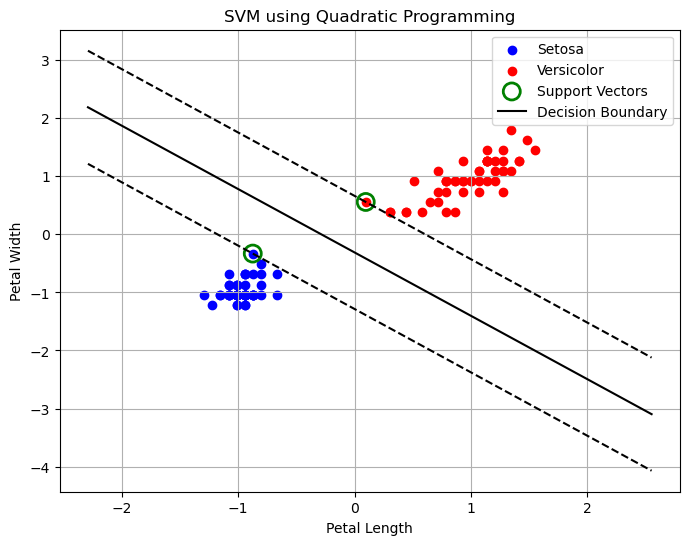

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X[y==-1][:,0],
    X[y==-1][:,1],
    color='blue',
    label='Setosa'
)

plt.scatter(
    X[y==1][:,0],
    X[y==1][:,1],
    color='red',
    label='Versicolor'
)

# Highlight support vectors
plt.scatter(
    X[svm.support_vectors][:,0],
    X[svm.support_vectors][:,1],
    s=150,
    facecolors='none',
    edgecolors='green',
    linewidths=2,
    label='Support Vectors'
)

x = np.linspace(
    X[:,0].min()-1,
    X[:,0].max()+1,
    100
)

decision = -(svm.w[0]*x + svm.b)/svm.w[1]

margin1 = -(svm.w[0]*x + svm.b - 1)/svm.w[1]

margin2 = -(svm.w[0]*x + svm.b + 1)/svm.w[1]

plt.plot(x, decision, 'k', label='Decision Boundary')
plt.plot(x, margin1, 'k--')
plt.plot(x, margin2, 'k--')

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("SVM using Quadratic Programming")

plt.grid(True)
plt.legend()

plt.show()

In [23]:
sample = np.array([[4.8, 1.6]])

sample = scaler.transform(sample)

prediction = svm.predict(sample)

if prediction == -1:
    print("Predicted Class : Setosa")
else:
    print("Predicted Class : Versicolor")

Predicted Class : Versicolor
